MOBILE LEGENDS

testing road to mythical glory

# Google Play Store ML Activity

End-to-end workflow: inspect, clean, visualize, model, evaluate, and interpret results.

AI SHIT GO BRRR

In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style='whitegrid')

## 1) Load Dataset

In [3]:
df_raw = pd.read_csv('dataset/googleplaystore.csv')
df_raw.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## 2) Inspect Data

In [4]:
print('Shape:', df_raw.shape)
display(df_raw.info())
display(df_raw.describe(include='all').T.head(15))
display(df_raw.isna().sum().sort_values(ascending=False).head(10))

Shape: (10841, 13)
<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
App,10841,9660,ROBLOX,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,10841,34,FAMILY,1972,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,9367.0,NaN,NaN,NaN,4.193338,0.537431,1.0,4.0,4.3,4.5,19.0
Reviews,10841,6002,0,596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,10841,462,Varies with device,1695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Installs,10841,22,"1,000,000+",1579,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10840,3,Free,10039,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,10841,93,0,10040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Content Rating,10840,6,Everyone,8714,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Genres,10841,120,Tools,842,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Rating            1474
Current Ver          8
Android Ver          3
Content Rating       1
Type                 1
Size                 0
Reviews              0
Category             0
App                  0
Price                0
dtype: int64

## 3) Clean Data

Main cleaning steps:
- Remove duplicate apps
- Convert `Reviews`, `Installs`, `Price`, and `Size` to numeric
- Remove invalid ratings (`Rating > 5`)
- Fill remaining missing values for key fields

In [5]:
df = df_raw.copy()

# Keep one row per app
df = df.drop_duplicates(subset='App').reset_index(drop=True)

# Rating cleanup
df.loc[df['Rating'] > 5, 'Rating'] = np.nan
df['Rating'] = df['Rating'].fillna(df['Rating'].median())

# Reviews to numeric
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df['Reviews'] = df['Reviews'].fillna(df['Reviews'].median())

# Installs like 1,000+ -> 1000
df['Installs'] = (
    df['Installs']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')
df['Installs'] = df['Installs'].fillna(df['Installs'].median())

# Price like $4.99 -> 4.99
df['Price'] = df['Price'].astype(str).str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce').fillna(0)

# Size like 14M / 300k -> MB
def size_to_mb(x):
    s = str(x).strip()
    if s == 'Varies with device' or s == 'nan':
        return np.nan
    if s.endswith('M'):
        return float(s[:-1])
    if s.endswith('k'):
        return float(s[:-1]) / 1024
    return np.nan

df['SizeMB'] = df['Size'].apply(size_to_mb)
df['SizeMB'] = df['SizeMB'].fillna(df['SizeMB'].median())

# Keep needed columns for this task
model_df = df[['Category', 'Content Rating', 'Genres', 'Rating', 'Reviews', 'Installs', 'Price', 'SizeMB', 'Type']].copy()
model_df = model_df.dropna(subset=['Type']).reset_index(drop=True)

print('Cleaned shape:', model_df.shape)
model_df.head()

Cleaned shape: (9659, 9)


,Category,Content Rating,Genres,Rating,Reviews,Installs,Price,SizeMB,Type
0,ART_AND_DESIGN,Everyone,Art & Design,4.1,159.0,10000.0,0.0,19.0,Free
1,ART_AND_DESIGN,Everyone,Art & Design;Pretend Play,3.9,967.0,500000.0,0.0,14.0,Free
2,ART_AND_DESIGN,Everyone,Art & Design,4.7,87510.0,5000000.0,0.0,8.7,Free
3,ART_AND_DESIGN,Teen,Art & Design,4.5,215644.0,50000000.0,0.0,25.0,Free
4,ART_AND_DESIGN,Everyone,Art & Design;Creativity,4.3,967.0,100000.0,0.0,2.8,Free


In [6]:
print('Remaining missing values:')
model_df.isna().sum().sort_values(ascending=False)

Remaining missing values:


Content Rating    1
Category          0
Genres            0
Rating            0
Reviews           0
Installs          0
Price             0
SizeMB            0
Type              0
dtype: int64

## 4) Exploratory Visualizations

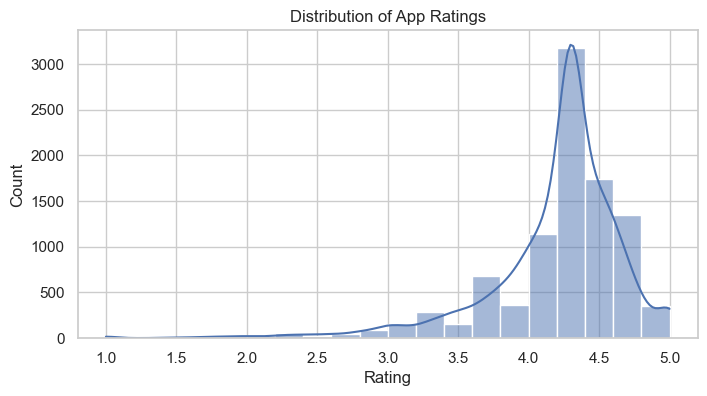

In [7]:
plt.figure(figsize=(8, 4))
sns.histplot(model_df['Rating'], bins=20, kde=True)
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.show()

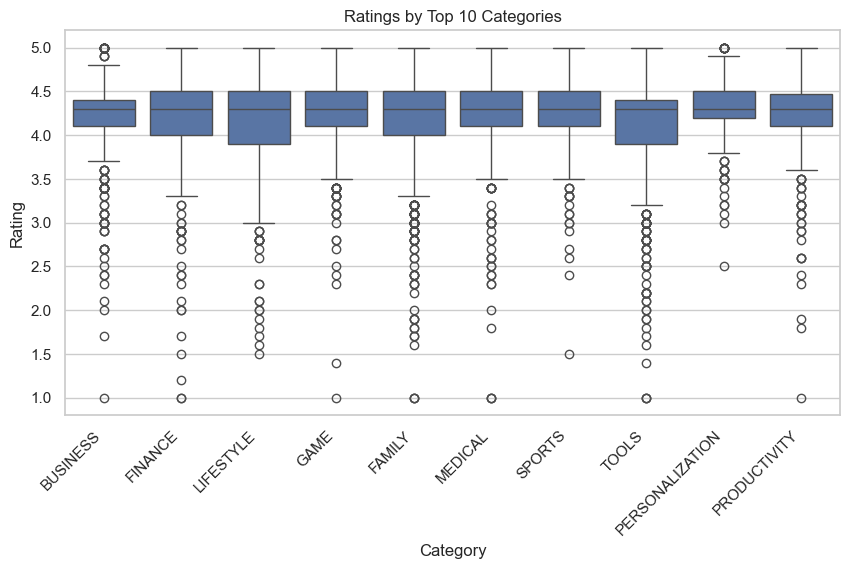

In [8]:
top_categories = model_df['Category'].value_counts().head(10).index
plot_df = model_df[model_df['Category'].isin(top_categories)]

plt.figure(figsize=(10, 5))
sns.boxplot(data=plot_df, x='Category', y='Rating')
plt.title('Ratings by Top 10 Categories')
plt.xticks(rotation=45, ha='right')
plt.show()

## 5) Prepare Features and Target

Task: classification where target is `Type` (`Free` vs `Paid`).

In [10]:
data = model_df.copy()

# Normalize target labels and keep only valid classes
data['Type'] = data['Type'].astype(str).str.strip().str.title()
data = data[data['Type'].isin(['Free', 'Paid'])].copy()
data['Type'] = data['Type'].map({'Free': 0, 'Paid': 1}).astype(int)

# One-hot encode categorical columns
X = pd.get_dummies(
    data.drop(columns=['Type']),
    columns=['Category', 'Content Rating', 'Genres'],
    drop_first=True
)
y = data['Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)
print('Class balance in y (0=Free, 1=Paid):')
print(y.value_counts(normalize=True))

X_train shape: (7726, 159)
X_test shape : (1932, 159)
Class balance in y (0=Free, 1=Paid):
Type
0    0.921723
1    0.078277
Name: proportion, dtype: float64


## 6) Train Models

In [11]:
# Scale for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
pred_lr = log_reg.predict(X_test_scaled)

tree = DecisionTreeClassifier(max_depth=8, random_state=42)
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)

## 7) Evaluate Models

In [12]:
acc_lr = accuracy_score(y_test, pred_lr)
acc_tree = accuracy_score(y_test, pred_tree)

print(f'Logistic Regression Accuracy: {acc_lr:.4f}')
print(f'Decision Tree Accuracy      : {acc_tree:.4f}')

print('\nClassification Report - Logistic Regression')
print(classification_report(y_test, pred_lr))

print('Classification Report - Decision Tree')
print(classification_report(y_test, pred_tree))

Logistic Regression Accuracy: 0.9695
Decision Tree Accuracy      : 1.0000

Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1781
           1       0.99      0.62      0.76       151

    accuracy                           0.97      1932
   macro avg       0.98      0.81      0.87      1932
weighted avg       0.97      0.97      0.97      1932

Classification Report - Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1781
           1       1.00      1.00      1.00       151

    accuracy                           1.00      1932
   macro avg       1.00      1.00      1.00      1932
weighted avg       1.00      1.00      1.00      1932



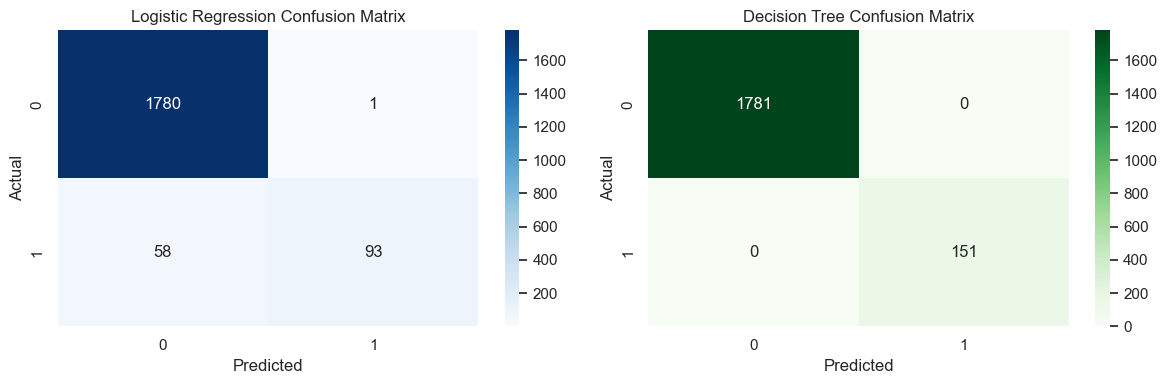

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_lr = confusion_matrix(y_test, pred_lr)
cm_tree = confusion_matrix(y_test, pred_tree)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Decision Tree Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 8) Interpretation Guide

Write your final insights here:
1. Which model performed better and by how much?
2. Which features seem important for distinguishing Free vs Paid apps?
3. What data quality issues likely affected results?
4. What would you improve next (more features, balancing, other models)?